In [1]:
# 1. repo principale
!rm -rf rfi-detection-radioastronomy
!git clone https://github.com/y99dr4s1ll/rfi-detection-radioastronomy.git
%cd rfi-detection-radioastronomy

# 2. RFI-NLN
%cd /kaggle/working
!git clone https://github.com/mesarcik/RFI-NLN.git
%cd rfi-detection-radioastronomy

!pip install faiss-gpu
!pip install aoflagger

Cloning into 'rfi-detection-radioastronomy'...
remote: Enumerating objects: 254, done.
remote: Counting objects: 100% (254/254), done.
remote: Compressing objects: 100% (182/182), done.
remote: Total 254 (delta 142), reused 174 (delta 62), pack-reused 0 (from 0)
Receiving objects: 100% (254/254), 50.01 KiB | 12.50 MiB/s, done.
Resolving deltas: 100% (142/142), done.
/kaggle/working/rfi-detection-radioastronomy
/kaggle/working
Cloning into 'RFI-NLN'...
remote: Enumerating objects: 1028, done.
remote: Counting objects: 100% (181/181), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 1028 (delta 123), reused 123 (delta 115), pack-reused 847 (from 1)
Receiving objects: 100% (1028/1028), 210.90 KiB | 17.58 MiB/s, done.
Resolving deltas: 100% (731/731), done.
/kaggle/working/rfi-detection-radioastronomy
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 22.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 76.1 MB/s eta 0:00:00:00

In [ ]:
'''import importlib.util
spec = importlib.util.spec_from_file_location(
    "processor", 
    "/kaggle/working/RFI-NLN/utils/data/processor.py"
)
processor = importlib.util.module_from_spec(spec)
spec.loader.exec_module(processor)
process = processor.process'''

# CUSUM

In [9]:
# Standard library
import os
import sys

# Third party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score

# Project
sys.path.insert(0, '/kaggle/working/rfi-detection-radioastronomy/src')
from loaders.luserna_loader import load_luserna, load_luserna_truth
from preprocessing.spectrogram import polynomial_detrend, extract_and_split_patches
from methods.statistical.cusum import CUSUM
from evaluation.metrics import compute_metrics
from evaluation.timing import Timer
from visualization.plots import plot_detection_result, plot_rfi_distribution

In [ ]:
import yaml

with open('experiments/configs/cusum_luserna.yaml') as f:
    cfg = yaml.safe_load(f)

# override path Kaggle
cfg['data_path'] = '/kaggle/input/spockdatasetsh5pg01'
cfg['truth_path'] = '/kaggle/input/spock-truth-h5-pg01'

# override parametri
cfg['k'] = 0.6
cfg['h'] = 0.3

# --- LOAD ---
print('Loading data...')
data = load_luserna(cfg['name'], path=cfg['data_path'], powers=False)
truth = load_luserna_truth(path=cfg['truth_path'])

data_np = data.to_numpy().astype(np.float32)
truth_np = truth.to_numpy().astype(bool)

# --- PREPROCESSING ---
print('Preprocessing...')

data_np = polynomial_detrend(data_np, degree=2)
data_np = np.clip(data_np, -10, 10)
data_np = process(data_np[..., np.newaxis], per_image=False)[..., 0]

train_data, train_masks, test_data, test_masks = extract_and_split_patches(
    data_np, truth_np,
    patch_size=tuple(cfg['patch_size']),
    train_size=cfg['train_size'],
    max_patches=cfg['max_patches'],
    random_seed=cfg['random_seed']
)

# --- INFERENCE ---
K = cfg['k']
H = cfg['h']
print(f'Running CUSUM (k={K}, h={H}) on {test_data.shape[0]} patches...')

pred_masks = np.zeros(test_masks.shape, dtype=bool)

with Timer() as t:
    for v in range(test_data.shape[0]):
        pred_masks[v, ..., 0] = CUSUM(test_data[v, ..., 0], k=K, h=H, output=False)

print(f'Inference time: {t}')

# --- METRICS ---
metrics = compute_metrics(test_masks, pred_masks)
metrics['time_seconds'] = t.elapsed
metrics['k'] = K
metrics['h'] = H
metrics['dataset'] = cfg['dataset']
metrics['method'] = 'cusum'

print(f"\nResults:")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1        : {metrics['f1']:.4f}")
print(f"  Time      : {metrics['time_seconds']:.2f}s")

# --- SAVE ---
import os
os.makedirs(os.path.dirname(cfg['results_path']), exist_ok=True)
pd.DataFrame([metrics]).to_csv(cfg['results_path'], index=False)
print(f'\nResults saved to {cfg["results_path"]}')

# --- PLOT ---
rfi_patches = np.where(np.any(test_masks > 0, axis=(1, 2, 3)))[0]
sample_idx = rfi_patches[0] if len(rfi_patches) > 0 else 0
plot_detection_result(
    spectrogram=test_data[sample_idx],
    ground_truth=test_masks[sample_idx],
    predicted_mask=pred_masks[sample_idx],
    title=f'CUSUM — k={K}, h={H}',
    save_path=cfg['plot_path']
)

In [ ]:
from visualization.plots import plot_rfi_distribution

plot_rfi_distribution(test_data, test_masks, title='RFI vs Clean distribution')

In [ ]:
### GRIDSEARCH singolo

data = train_data[135, ...]
truth_mask = train_masks[135, ...]

# Definizione dei range per k e h
# Definizione dei range per k e h
k_values = np.arange(0.25, 0.45, 0.01)  # da 0.1 a 2 in passi di 0.05
h_values = np.arange(0.1, 1, 0.05)       # da 1 a 6 in passi di 0.5

# Creo liste per salvare i risultati
results = []

# Doppio ciclo con barra di progresso
total_iterations = len(k_values) * len(h_values)
pbar = tqdm(total=total_iterations, desc='Analyzing parameters')

for k in k_values:
    for h in h_values:
        # Calcolo la maschera predetta
        pred_mask = CUSUM(data, k=k, h=h, output=False)
        
        # Appiattisco le maschere
        truth_flat = truth_mask.flatten()
        pred_flat = pred_mask.flatten()
        
        # Calcolo metriche
        accuracy = accuracy_score(truth_flat, pred_flat)
        precision = precision_score(truth_flat, pred_flat)
        recall = recall_score(truth_flat, pred_flat)
        f1 = f1_score(truth_flat, pred_flat)
        iou = jaccard_score(truth_flat, pred_flat)
        
        # Salvo i risultati
        results.append({
            'k': k,
            'h': h,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'iou': iou
        })
        
        pbar.update(1)

pbar.close()

# Creo il DataFrame
df_results = pd.DataFrame(results)

# Mostro i primi risultati
print("\nPrimi risultati:")
print(df_results.head())

# Trovo i parametri migliori per ogni metrica
best_params = {
    'accuracy': df_results.loc[df_results['accuracy'].idxmax()],
    'precision': df_results.loc[df_results['precision'].idxmax()],
    'recall': df_results.loc[df_results['recall'].idxmax()],
    'f1': df_results.loc[df_results['f1'].idxmax()],
    'iou': df_results.loc[df_results['iou'].idxmax()]
}

print("\nMigliori parametri per ogni metrica:")
for metric, params in best_params.items():
    print(f"\n{metric.upper()}:")
    print(f"k={params['k']:.2f}, h={params['h']:.1f}")
    print(f"Valore: {params[metric]:.4f}")

# Salvo il DataFrame in csv se necessario
df_results.to_csv('parameter_analysis.csv', index=False)

# SUMTHRESHOLD

In [ ]:
import yaml
import faiss

with open('experiments/configs/sum_threshold_luserna.yaml') as f:
    cfg = yaml.safe_load(f)

cfg['data_path'] = '/kaggle/input/spockdatasetsh5pg01'
cfg['truth_path'] = '/kaggle/input/spock-truth-h5-pg01'

with open('experiments/configs/sum_threshold_luserna.yaml', 'w') as f:
    yaml.dump(cfg, f)

!python experiments/run_sum_threshold_luserna.py

# KNN

In [ ]:
!python experiments/run_ml.py \
    --config experiments/configs/knn_luserna.yaml \
    --rfinln_path /kaggle/working/RFI-NLN \
    --data_path /kaggle/input/spockdatasetsh5pg01 \
    --truth_path /kaggle/input/spock-truth-h5-pg01

# RFC

In [ ]:
!python experiments/run_ml.py \
    --config experiments/configs/rf_luserna.yaml \
    --rfinln_path /kaggle/working/RFI-NLN \
    --data_path /kaggle/input/spockdatasetsh5pg01 \
    --truth_path /kaggle/input/spock-truth-h5-pg01 \
    --skip_features

# UNET

In [ ]:
!python experiments/run_dl.py \
    --config experiments/configs/unet_luserna.yaml \
    --rfinln_path /kaggle/working/RFI-NLN \
    --data_path /kaggle/input/spockdatasetsh5pg01 \
    --truth_path /kaggle/input/spock-truth-h5-pg01

# RNET

In [2]:
!python experiments/run_dl.py \
    --config experiments/configs/rnet_luserna.yaml \
    --rfinln_path /kaggle/working/RFI-NLN \
    --data_path /kaggle/input/spockdatasetsh5pg01 \
    --truth_path /kaggle/input/spock-truth-h5-pg01

2026-03-10 20:32:12.219930: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-10 20:32:12.220070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-10 20:32:12.339682: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/kaggle/working/RFI-NLN/utils/data/augmentation.py:66: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(images.shape[1] *0.9 > crop_size[0], ValueError,
/kaggle/working/RFI-NLN/utils/data/augmentation.py:68: SyntaxWarning: assertion is always true, perhaps remove parentheses?
  assert(images.shape[2]*0.9 > crop_size[1], ValueError,
Lo

# MORAN EXP

In [3]:
# Cella 1 - imports e path
import sys
sys.path.insert(0, '/kaggle/working/RFI-NLN')
sys.path.insert(0, '/kaggle/working/rfi-detection-radioastronomy/src')

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import Layer
from utils.data import patches, get_patches
from utils.data.processor import process
from utils.training import print_epoch

2026-03-10 20:39:13.278454: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-10 20:39:13.278538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-10 20:39:13.280029: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
# Cella 2 - LocalMoranLayer
class LocalMoranLayer(Layer):
    def __init__(self, w_size=5, **kwargs):
        super(LocalMoranLayer, self).__init__(**kwargs)
        self.w_size = w_size

    def build(self, input_shape):
        kernel = np.ones((self.w_size, self.w_size, 1, 1), dtype=np.float32)
        kernel /= self.w_size ** 2
        self.W = tf.constant(kernel, dtype=tf.float32)
        super(LocalMoranLayer, self).build(input_shape)

    def call(self, inputs):
        channels = tf.split(inputs, inputs.shape[-1], axis=-1)
        moran_channels = []
        for ch in channels:
            mean = tf.nn.conv2d(ch, self.W, strides=[1,1,1,1], padding='SAME')
            centered = ch - mean
            lag = tf.nn.conv2d(centered, self.W, strides=[1,1,1,1], padding='SAME')
            variance = tf.nn.conv2d(tf.square(centered), self.W, strides=[1,1,1,1], padding='SAME')
            moran = (centered * lag) / (variance + tf.keras.backend.epsilon())
            moran_channels.append(moran)
        return tf.concat(moran_channels, axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({'w_size': self.w_size})
        return config

In [5]:
# 1. Output sigmoid invece di relu

# 2. BCE con class weights
#pos_weight = np.sum(train_masks_p == 0) / (np.sum(train_masks_p > 0) + 1e-7)
pos_weight = 10

print(f'Positive weight: {pos_weight:.1f}')

def weighted_bce(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()
    weights = y_true * pos_weight + (1 - y_true)
    return tf.reduce_mean(weights * tf.keras.backend.binary_crossentropy(y_true, y_pred))

Positive weight: 10.0


In [15]:
def RNET_MORAN(args, dropout: float = 0.05, w_size: int = 5):
    """
    R-Net with a Local Moran parallel branch on the first residual block.

    Architecture:
        input → Conv → BN → ReLU → xp
        xp → Block1 → Block2 → x2
        x2 + xp → x3 (residual 1)

        At x3: parallel branch
            ├── standard path → Block3 → Block4
            └── Moran path    → LocalMoran
                                ↓
                           concatenate
                                ↓
                           Conv1x1 → merge
                                ↓
                           x7 = merge + x3 (residual 2)
                                ↓
                           Block5 → output

    Args:
        args: Args object with input_shape.
        dropout: Dropout rate. Default is 0.05.
        w_size: Neighborhood size for LocalMoranLayer. Default is 5.

    Returns:
        tf.keras.Model: R-Net with Moran branch.
    """
    input_data = tf.keras.Input(args.input_shape, name='data')

    # --- Stem ---
    xp = layers.Conv2D(filters=12, kernel_size=5, strides=(1, 1), padding='same')(input_data)
    x = layers.BatchNormalization()(xp)
    x = layers.Activation('relu')(x)

    # --- Block 1 ---
    x1 = layers.Conv2D(filters=12, kernel_size=5, strides=(1, 1), padding='same')(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Activation('relu')(x1)
    if dropout > 0:
        x1 = layers.Dropout(dropout)(x1)

    # --- Block 2 ---
    x2 = layers.Conv2D(filters=12, kernel_size=5, strides=(1, 1), padding='same')(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Activation('relu')(x2)

    # --- Residual 1 ---
    x3 = x2 + xp
    if dropout > 0:
        x3 = layers.Dropout(dropout)(x3)

    # --- Parallel branch at x3 ---

    # Standard path
    x4 = layers.Conv2D(filters=12, kernel_size=5, strides=(1, 1), padding='same')(x3)
    x4 = layers.BatchNormalization()(x4)
    x4 = layers.Activation('relu')(x4)

    x6 = layers.Conv2D(filters=12, kernel_size=5, strides=(1, 1), padding='same')(x4)
    x6 = layers.BatchNormalization()(x6)
    x6 = layers.Activation('relu')(x6)
    if dropout > 0:
        x6 = layers.Dropout(dropout)(x6)

    # Moran path
    moran = LocalMoranLayer(w_size=w_size, name='local_moran')(x3)

    # Merge via concatenation + Conv1x1
    merged = layers.Concatenate(axis=-1)([x6, moran])
    merged = layers.Conv2D(
        filters=12, kernel_size=1, strides=(1, 1), padding='same', name='moran_merge'
    )(merged)
    merged = layers.BatchNormalization()(merged)
    merged = layers.Activation('relu')(merged)

    # --- Residual 2 ---
    x7 = merged + x3

    # --- Block 5 ---
    x8 = layers.Conv2D(filters=12, kernel_size=5, strides=(1, 1), padding='same')(x7)
    x8 = layers.BatchNormalization()(x8)
    x8 = layers.Activation('relu')(x8)

    # --- Output ---
    x_out = layers.Conv2D(
    filters=1, kernel_size=5, strides=(1,1), padding='same', activation='sigmoid'
    )(x8)


    return tf.keras.Model(inputs=[input_data], outputs=[x_out])


def build_rnet_moran(args, dropout: float = 0.05, w_size: int = 5):
    """
    Wrapper to build R-Net with Moran branch.

    Args:
        args: Args object with input_shape.
        dropout: Dropout rate. Default is 0.05.
        w_size: Neighborhood size for LocalMoranLayer. Default is 5.

    Returns:
        tf.keras.Model: R-Net with Moran branch.
    """
    return RNET_MORAN(args, dropout=dropout, w_size=w_size)


def train_rnet_moran(
    model,
    train_data: np.ndarray,
    train_masks: np.ndarray,
    epochs: int = 500,
    batch_size: int = 1024,
    learning_rate: float = 1e-4,
    buffer_size: int = 64
):
    """
    Trains R-Net with Moran branch.

    Args:
        model: R-Net Moran model instance.
        train_data: Training data of shape (n, h, w, 1).
        train_masks: Training masks of shape (n, h, w, 1).
        epochs: Number of training epochs. Default is 500.
        batch_size: Batch size. Default is 1024.
        learning_rate: Learning rate for Adam optimizer. Default is 1e-4.
        buffer_size: Shuffle buffer size. Default is 64.

    Returns:
        Trained model.
    """
    from utils.training import print_epoch

    bce = tf.keras.losses.BinaryCrossentropy()
    optimizer = tf.keras.optimizers.Adam(learning_rate)

    m_precision = tf.keras.metrics.Precision()
    m_recall = tf.keras.metrics.Recall()
    m_accuracy = tf.keras.metrics.BinaryAccuracy()

    @tf.function
    def train_step(x, y):
        with tf.GradientTape() as tape:
            x_hat = model(x, training=True)
            #loss = bce(x_hat, y)
            loss = weighted_bce(y, x_hat)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        pred = tf.cast(x_hat > 0.5, tf.float32)
        m_precision.update_state(y, pred)
        m_recall.update_state(y, pred)
        m_accuracy.update_state(y, pred)

        precision = m_precision.result()
        recall = m_recall.result()
        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)

        return loss, m_accuracy.result(), precision, recall, f1

    train_data_ds = (
        tf.data.Dataset.from_tensor_slices(train_data)
        .shuffle(buffer_size, seed=42)
        .batch(batch_size)
    )
    train_masks_ds = (
        tf.data.Dataset.from_tensor_slices(train_masks.astype('float32'))
        .shuffle(buffer_size, seed=42)
        .batch(batch_size)
    )

    for epoch in range(epochs):
        start = time.time()
        for image_batch, mask_batch in zip(train_data_ds, train_masks_ds):
            loss, accuracy, precision, recall, f1 = train_step(image_batch, mask_batch)

        print_epoch('RNET_MORAN', epoch, time.time() - start, {
            'Loss': loss.numpy(),
            'Accuracy': accuracy.numpy(),
            'Precision': precision.numpy(),
            'Recall': recall.numpy(),
            'F1': f1.numpy()
        }, None)

    return model

# Cella - training con raccolta metriche
'''history = {
    'loss': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}'''
def train_rnet_moran_tracked(model, train_data, train_masks, epochs=50, 
                              batch_size=64, learning_rate=1e-4, buffer_size=64, 
                              pos_weight=10, use_weighted_bce=False):
    history = {'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    
    bce = tf.keras.losses.BinaryCrossentropy()
    
    def weighted_bce(y_true, y_pred):
        weights = y_true * pos_weight + (1 - y_true)
        return tf.reduce_mean(weights * tf.keras.backend.binary_crossentropy(y_true, y_pred))
    
    loss_fn = weighted_bce if use_weighted_bce else bce
    # resto invariato, sostituisci loss = weighted_bce(...) con loss = loss_fn(y, x_hat)

    
    optimizer = tf.keras.optimizers.Adam(learning_rate)
    m_precision = tf.keras.metrics.Precision()
    m_recall = tf.keras.metrics.Recall()
    m_accuracy = tf.keras.metrics.BinaryAccuracy()

    @tf.function
    def train_step(x, y):
        with tf.GradientTape() as tape:
            x_hat = model(x, training=True)
            loss = weighted_bce(y, x_hat)
        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        pred = tf.cast(x_hat > 0.5, tf.float32)
        m_precision.update_state(y, pred)
        m_recall.update_state(y, pred)
        m_accuracy.update_state(y, pred)
        precision = m_precision.result()
        recall = m_recall.result()
        f1 = 2 * (precision * recall) / (precision + recall + 1e-7)
        return loss, m_accuracy.result(), precision, recall, f1

    train_data_ds = tf.data.Dataset.from_tensor_slices(train_data).shuffle(buffer_size, seed=42).batch(batch_size)
    train_masks_ds = tf.data.Dataset.from_tensor_slices(train_masks.astype('float32')).shuffle(buffer_size, seed=42).batch(batch_size)

    for epoch in range(epochs):
        start = time.time()
        for image_batch, mask_batch in zip(train_data_ds, train_masks_ds):
            loss, accuracy, precision, recall, f1 = train_step(image_batch, mask_batch)
        
        history['loss'].append(loss.numpy())
        history['accuracy'].append(accuracy.numpy())
        history['precision'].append(precision.numpy())
        history['recall'].append(recall.numpy())
        history['f1'].append(f1.numpy())
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d} | Loss: {loss.numpy():.4f} | P: {precision.numpy():.4f} | R: {recall.numpy():.4f} | F1: {f1.numpy():.4f} | {time.time()-start:.1f}s')
    
    return model, history

In [7]:
from loaders.lofar_loader import Args

args = Args()
args.patch_x = 32
args.patch_y = 32
args.update_input_shape()

In [10]:
import yaml

with open('experiments/configs/cusum_luserna.yaml') as f:
    cfg = yaml.safe_load(f)

# override path Kaggle
cfg['data_path'] = '/kaggle/input/spockdatasetsh5pg01'
cfg['truth_path'] = '/kaggle/input/spock-truth-h5-pg01'

# override parametri
cfg['k'] = 0.6
cfg['h'] = 0.3

# --- LOAD ---
print('Loading data...')
data = load_luserna(cfg['name'], path=cfg['data_path'], powers=False)
truth = load_luserna_truth(path=cfg['truth_path'])

data_np = data.to_numpy().astype(np.float32)
truth_np = truth.to_numpy().astype(bool)

# --- PREPROCESSING ---
print('Preprocessing...')

data_np = polynomial_detrend(data_np, degree=2)
data_np = np.clip(data_np, -10, 10)
data_np = process(data_np[..., np.newaxis], per_image=False)[..., 0]

train_data, train_masks, test_data, test_masks = extract_and_split_patches(
    data_np, truth_np,
    patch_size=tuple(cfg['patch_size']),
    train_size=cfg['train_size'],
    max_patches=cfg['max_patches'],
    random_seed=cfg['random_seed']
)

from preprocessing.spectrogram import balance_dataset

# Balance 512x512
train_data_red, train_masks_red = balance_dataset(train_data, train_masks, random_seed=42)

# Patching 32x32
p_size = (1, 32, 32, 1)
s_size = (1, 32, 32, 1)
rate = (1, 1, 1, 1)

train_data_p = get_patches(train_data_red, None, p_size, s_size, rate, 'VALID')
train_masks_p = get_patches(train_masks_red.astype('float32'), None, p_size, s_size, rate, 'VALID')
test_data_p = get_patches(test_data, None, p_size, s_size, rate, 'VALID')
test_masks_p = get_patches(test_masks.astype('float32'), None, p_size, s_size, rate, 'VALID')

print(f'Train patches: {train_data_p.shape}')
print(f'Test patches: {test_data_p.shape}')

Loading data...
Preprocessing...
Train patches: (31744, 32, 32, 1)
Test patches: (30720, 32, 32, 1)


In [11]:
import time

In [41]:
model = RNET_MORAN(args, dropout=0.05, w_size=5)
trained_model = train_rnet_moran_tracked(model, train_data_p, train_masks_p, epochs=250)

Positive weight: 10.0


2026-03-10 19:27:33.033753: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_17_1/dropout_24_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch   0 | Loss: 0.6381 | P: 0.0044 | R: 0.4865 | F1: 0.0087 | 9.6s
Epoch  10 | Loss: 0.1583 | P: 0.0085 | R: 0.1194 | F1: 0.0158 | 4.9s
Epoch  20 | Loss: 0.1136 | P: 0.0296 | R: 0.2305 | F1: 0.0524 | 4.9s
Epoch  30 | Loss: 0.0991 | P: 0.0558 | R: 0.3186 | F1: 0.0950 | 4.9s
Epoch  40 | Loss: 0.0874 | P: 0.0814 | R: 0.3792 | F1: 0.1341 | 4.9s
Epoch  50 | Loss: 0.0840 | P: 0.1050 | R: 0.4228 | F1: 0.1682 | 4.9s
Epoch  60 | Loss: 0.0835 | P: 0.1261 | R: 0.4556 | F1: 0.1975 | 4.9s
Epoch  70 | Loss: 0.0764 | P: 0.1449 | R: 0.4813 | F1: 0.2228 | 4.9s
Epoch  80 | Loss: 0.0768 | P: 0.1617 | R: 0.5020 | F1: 0.2446 | 4.9s
Epoch  90 | Loss: 0.0780 | P: 0.1766 | R: 0.5191 | F1: 0.2636 | 4.9s
Epoch 100 | Loss: 0.0752 | P: 0.1901 | R: 0.5335 | F1: 0.2803 | 4.9s
Epoch 110 | Loss: 0.0703 | P: 0.2022 | R: 0.5458 | F1: 0.2950 | 4.9s
Epoch 120 | Loss: 0.0738 | P: 0.2131 | R: 0.5565 | F1: 0.3082 | 4.9s
Epoch 130 | Loss: 0.0691 | P: 0.2230 | R: 0.5658 | F1: 0.3199 | 4.9s
Epoch 140 | Loss: 0.0708 | P: 0.23

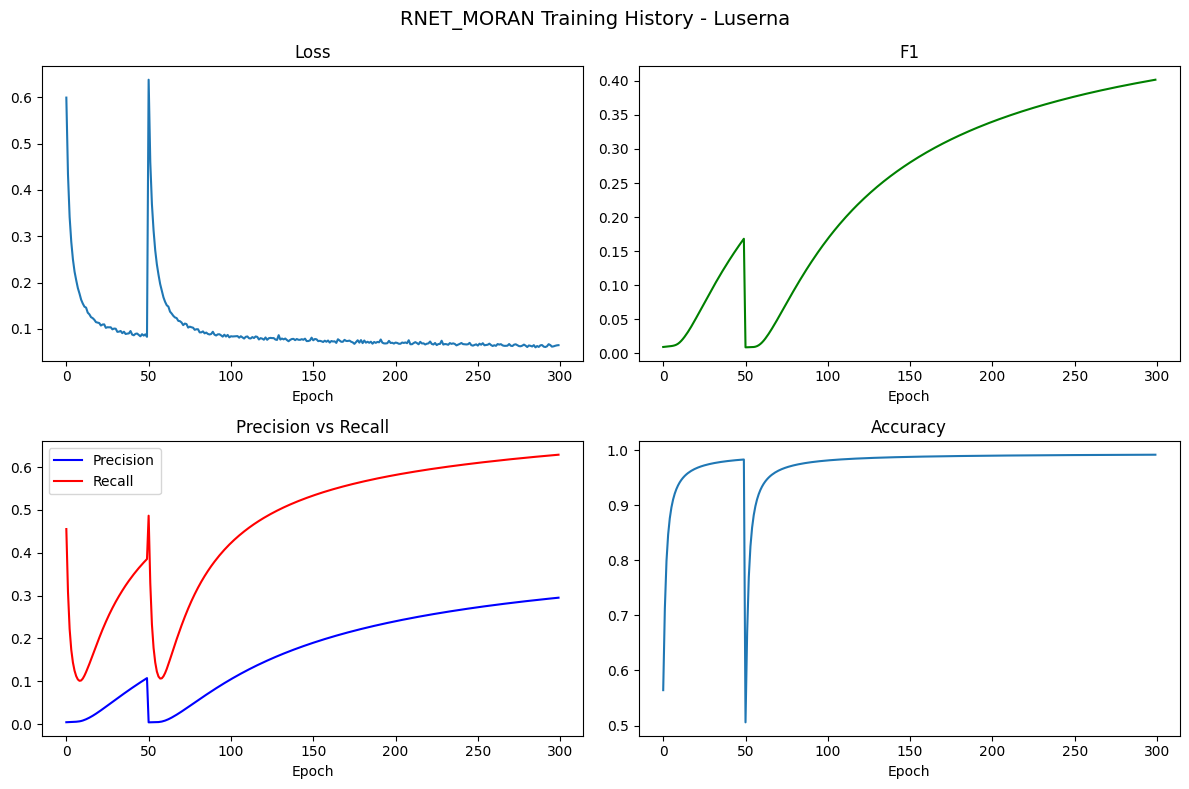

In [42]:
# Cella - plot history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('RNET_MORAN Training History - Luserna', fontsize=14)

axes[0,0].plot(history['loss'])
axes[0,0].set_title('Loss')
axes[0,0].set_xlabel('Epoch')

axes[0,1].plot(history['f1'], label='F1', color='green')
axes[0,1].set_title('F1')
axes[0,1].set_xlabel('Epoch')

axes[1,0].plot(history['precision'], label='Precision', color='blue')
axes[1,0].plot(history['recall'], label='Recall', color='red')
axes[1,0].set_title('Precision vs Recall')
axes[1,0].legend()
axes[1,0].set_xlabel('Epoch')

axes[1,1].plot(history['accuracy'])
axes[1,1].set_title('Accuracy')
axes[1,1].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step


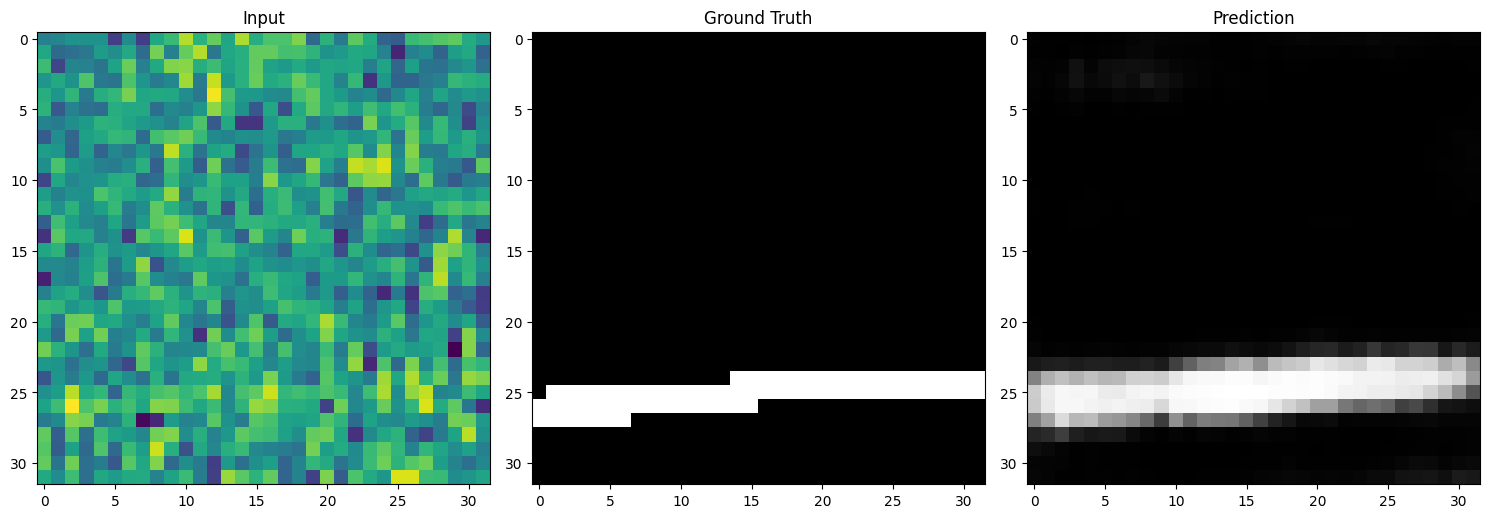

In [43]:
# Cella - plot predizione visiva su sample
import matplotlib.pyplot as plt

sample_idx = 983

pred = model.predict(test_data_p[sample_idx:sample_idx+1])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(test_data_p[sample_idx, ..., 0], cmap='viridis')
axes[0].set_title('Input')
axes[1].imshow(test_masks_p[sample_idx, ..., 0], cmap='gray')
axes[1].set_title('Ground Truth')
axes[2].imshow(pred[0, ..., 0], cmap='gray')
axes[2].set_title('Prediction')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


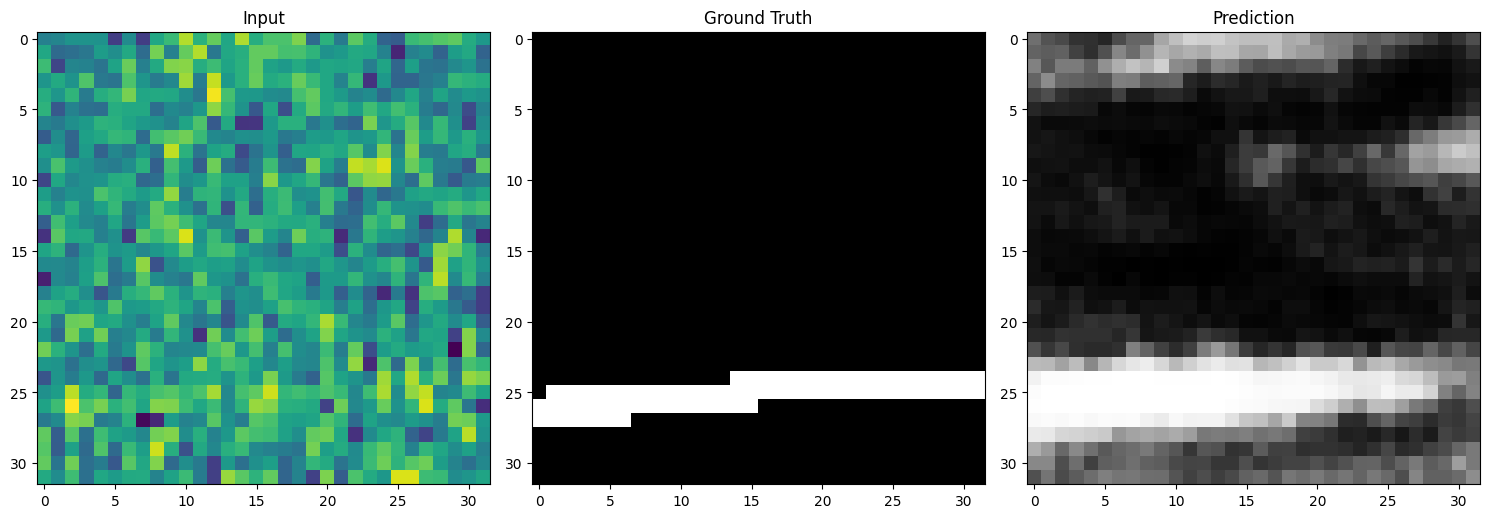

In [33]:
# Stessa architettura, stesso training, stesso seed
SEED = 42
POS_WEIGHT = 10
EPOCHS = 50

# Run 1 - R-Net base
tf.random.set_seed(SEED)
model_base = RNET(args, dropout=0.05)
trained_base, history_base = train_rnet_moran_tracked(
    model_base, train_data_p, train_masks_p, 
    epochs=EPOCHS, pos_weight=POS_WEIGHT
)

# Run 2 - R-Net + Moran
tf.random.set_seed(SEED)
model_moran = RNET_MORAN(args, dropout=0.05, w_size=5)
trained_moran, history_moran = train_rnet_moran_tracked(
    model_moran, train_data_p, train_masks_p,
    epochs=EPOCHS, pos_weight=POS_WEIGHT
)

In [17]:
from methods.dl.rnet import RNET, build_rnet, train_rnet
# Stessa architettura, stesso training, stesso seed
SEED = 42
POS_WEIGHT = 10
EPOCHS = 100

# Run 1 - R-Net base
tf.random.set_seed(42)
model_base = RNET(args, dropout=0.1)
trained_base, history_base = train_rnet_moran_tracked(
    model_base, train_data_p, train_masks_p,
    epochs=EPOCHS, pos_weight=10
)

# Run 2 - R-Net + Moran
tf.random.set_seed(SEED)
model_moran = RNET_MORAN(args, dropout=0.1, w_size=5)
trained_moran, history_moran = train_rnet_moran_tracked(
    model_moran, train_data_p, train_masks_p,
    epochs=EPOCHS, pos_weight=POS_WEIGHT
)

2026-03-10 20:56:21.422442: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_15_1/dropout_21_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch   0 | Loss: 0.4938 | P: 0.0069 | R: 0.0337 | F1: 0.0114 | 8.8s
Epoch  10 | Loss: 0.0454 | P: 0.0649 | R: 0.1999 | F1: 0.0980 | 5.1s
Epoch  20 | Loss: 0.0925 | P: 0.1060 | R: 0.3081 | F1: 0.1577 | 5.1s
Epoch  30 | Loss: 0.1055 | P: 0.1391 | R: 0.3372 | F1: 0.1970 | 5.1s
Epoch  40 | Loss: 0.0519 | P: 0.1583 | R: 0.3495 | F1: 0.2179 | 5.1s
Epoch  50 | Loss: 0.0241 | P: 0.1736 | R: 0.3631 | F1: 0.2349 | 5.1s
Epoch  60 | Loss: 0.0558 | P: 0.1878 | R: 0.3722 | F1: 0.2496 | 5.1s
Epoch  70 | Loss: 0.0512 | P: 0.2046 | R: 0.3848 | F1: 0.2671 | 5.1s
Epoch  80 | Loss: 0.0683 | P: 0.2111 | R: 0.3971 | F1: 0.2756 | 5.1s
Epoch  90 | Loss: 0.0797 | P: 0.2117 | R: 0.4036 | F1: 0.2777 | 5.1s


2026-03-10 21:04:57.758546: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_17_1/dropout_24_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Epoch   0 | Loss: 0.1310 | P: 0.0089 | R: 0.1123 | F1: 0.0165 | 12.8s
Epoch  10 | Loss: 0.0158 | P: 0.2030 | R: 0.5010 | F1: 0.2890 | 7.5s
Epoch  20 | Loss: 0.0241 | P: 0.2774 | R: 0.5763 | F1: 0.3746 | 7.5s
Epoch  30 | Loss: 0.0227 | P: 0.3131 | R: 0.6100 | F1: 0.4138 | 7.4s
Epoch  40 | Loss: 0.0177 | P: 0.3340 | R: 0.6300 | F1: 0.4365 | 7.5s
Epoch  50 | Loss: 0.0104 | P: 0.3476 | R: 0.6438 | F1: 0.4515 | 7.4s
Epoch  60 | Loss: 0.0218 | P: 0.3572 | R: 0.6541 | F1: 0.4621 | 7.5s
Epoch  70 | Loss: 0.0289 | P: 0.3644 | R: 0.6624 | F1: 0.4702 | 7.5s
Epoch  80 | Loss: 0.0265 | P: 0.3698 | R: 0.6693 | F1: 0.4764 | 7.5s
Epoch  90 | Loss: 0.0336 | P: 0.3739 | R: 0.6752 | F1: 0.4813 | 7.4s


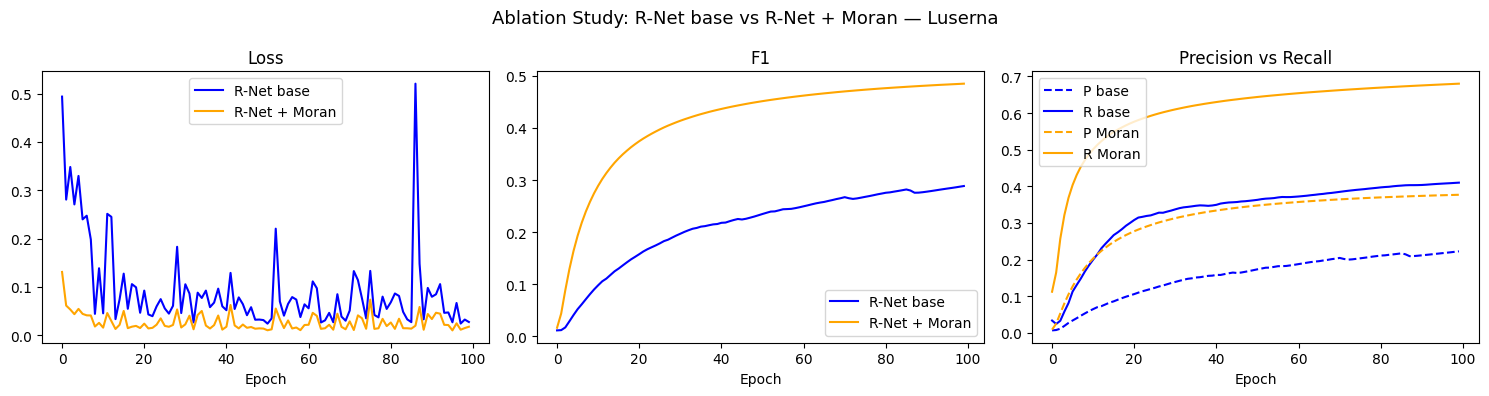

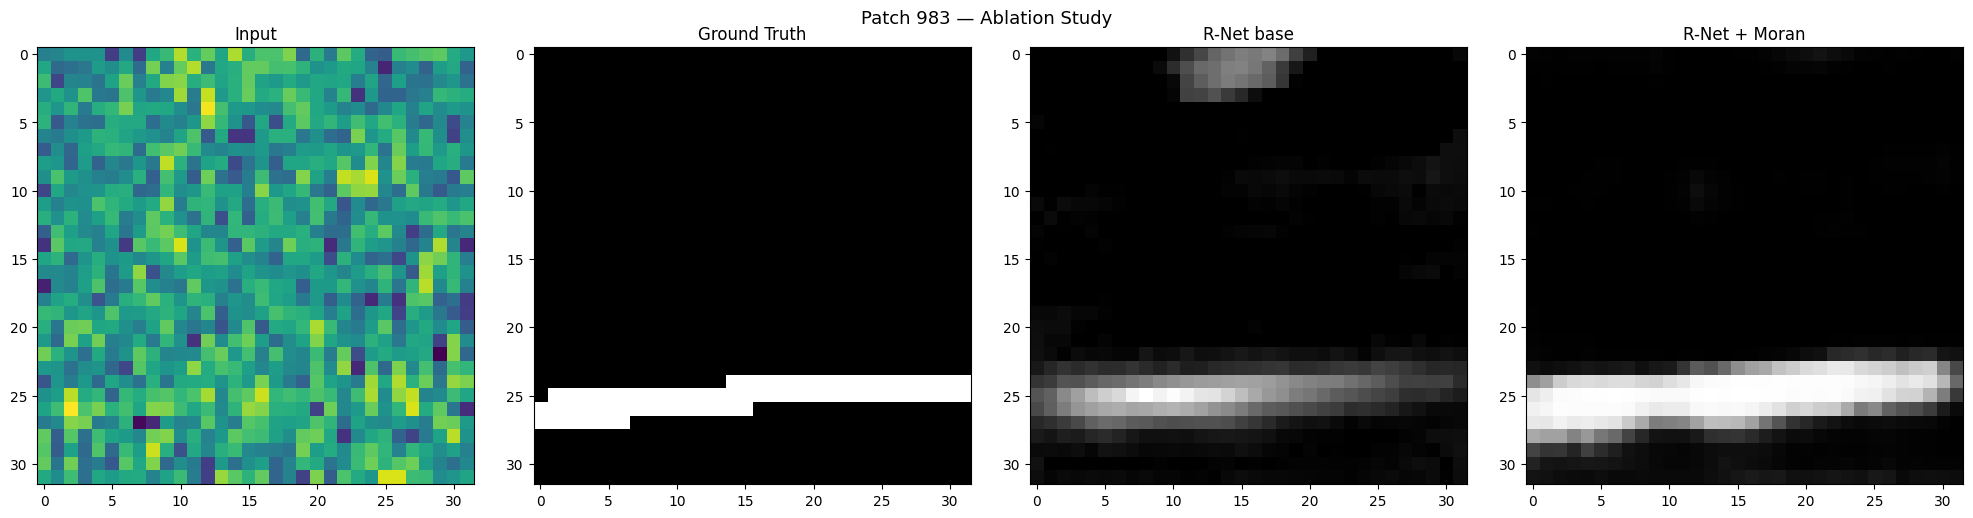

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Ablation Study: R-Net base vs R-Net + Moran — Luserna', fontsize=13)

# Loss
axes[0].plot(history_base['loss'], label='R-Net base', color='blue')
axes[0].plot(history_moran['loss'], label='R-Net + Moran', color='orange')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# F1
axes[1].plot(history_base['f1'], label='R-Net base', color='blue')
axes[1].plot(history_moran['f1'], label='R-Net + Moran', color='orange')
axes[1].set_title('F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# Precision vs Recall
axes[2].plot(history_base['precision'], label='P base', color='blue', linestyle='--')
axes[2].plot(history_base['recall'], label='R base', color='blue')
axes[2].plot(history_moran['precision'], label='P Moran', color='orange', linestyle='--')
axes[2].plot(history_moran['recall'], label='R Moran', color='orange')
axes[2].set_title('Precision vs Recall')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()# Plot visivo predizioni a confronto su stessa patch
sample_idx = 983

pred_base = trained_base.predict(test_data_p[sample_idx:sample_idx+1], verbose=0)
pred_moran = trained_moran.predict(test_data_p[sample_idx:sample_idx+1], verbose=0)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Patch {sample_idx} — Ablation Study', fontsize=13)

axes[0].imshow(test_data_p[sample_idx, ..., 0], cmap='viridis')
axes[0].set_title('Input')

axes[1].imshow(test_masks_p[sample_idx, ..., 0], cmap='gray')
axes[1].set_title('Ground Truth')

axes[2].imshow(pred_base[0, ..., 0], cmap='gray')
axes[2].set_title('R-Net base')

axes[3].imshow(pred_moran[0, ..., 0], cmap='gray')
axes[3].set_title('R-Net + Moran')

plt.tight_layout()
plt.show()

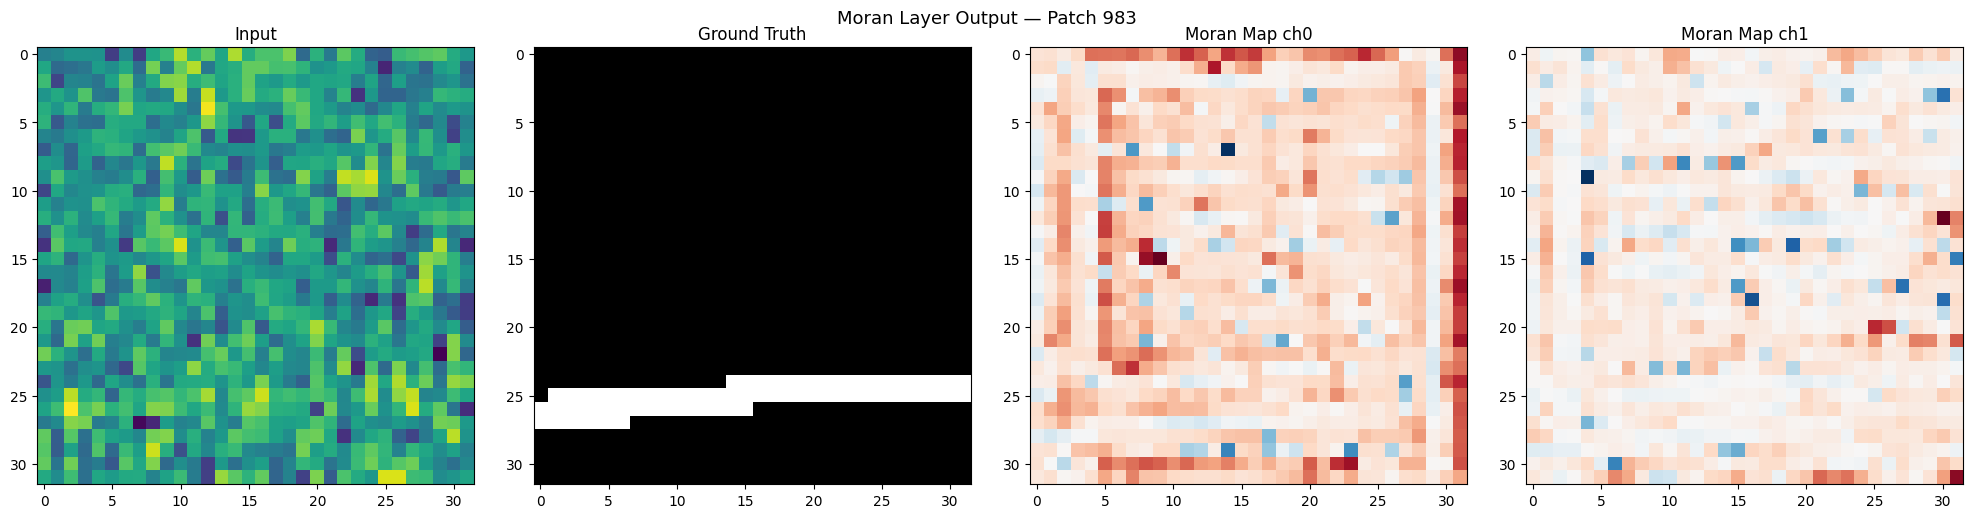

In [21]:
# Plot mappa Moran intermedia
moran_extractor = tf.keras.Model(
    inputs=trained_moran.input,
    outputs=trained_moran.get_layer('local_moran').output
)
moran_map = moran_extractor.predict(test_data_p[sample_idx:sample_idx+1], verbose=0)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Moran Layer Output — Patch {sample_idx}', fontsize=13)

axes[0].imshow(test_data_p[sample_idx, ..., 0], cmap='viridis')
axes[0].set_title('Input')

axes[1].imshow(test_masks_p[sample_idx, ..., 0], cmap='gray')
axes[1].set_title('Ground Truth')

for ch in range(min(2, moran_map.shape[-1])):
    axes[2+ch].imshow(moran_map[0, ..., ch], cmap='RdBu_r')
    axes[2+ch].set_title(f'Moran Map ch{ch}')

plt.tight_layout()
plt.show()